<a href="https://colab.research.google.com/github/muhammedali123-collab/pakistan-banking-dataset/blob/main/Pakistan_Banking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pakistan Banking Dataset

#Data Loading

In [81]:
from google.colab import files
uploaded =files.upload()

Saving pakistan_banking_dataset.csv to pakistan_banking_dataset (2).csv


In [2]:
#Import some basic libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
dataali = pd.read_csv('pakistan_banking_dataset.csv')
#Using data.head() we can see the top 5 rows of the dataset

#Exploratory Data Analysis

In [5]:
dataali.shape

(6000, 10)

In [6]:
dataali.head(5)

,Customer_ID,Age,Gender,City,Bank_Name,Account_Balance_PKR,Loan_Status,Credit_Score,Account_Type,Churn
0,1,56,Female,Karachi,UBL,1214138,No,455,Current,0
1,2,69,Female,Lahore,Allied Bank,1860696,No,682,Savings,0
2,3,46,Female,Faisalabad,UBL,1681369,Yes,619,Current,1
3,4,32,Male,Faisalabad,HBL,60650,No,672,Savings,1
4,5,60,Female,Lahore,Allied Bank,1727765,Yes,830,Savings,0


In [7]:
dataali.tail(3)

,Customer_ID,Age,Gender,City,Bank_Name,Account_Balance_PKR,Loan_Status,Credit_Score,Account_Type,Churn
5997,5998,44,Female,Lahore,Allied Bank,542374,Yes,618,Current,1
5998,5999,26,Male,Faisalabad,Meezan Bank,990086,No,410,Current,0
5999,6000,64,Male,Faisalabad,Allied Bank,895641,Yes,772,Current,1


In [8]:
dataali.describe()

,Customer_ID,Age,Account_Balance_PKR,Credit_Score,Churn
count,6000.000000,6000.000000,6.000000e+03,6000.000000,6000.000000
mean,3000.500000,43.677500,1.003041e+06,600.778667,0.513833
std,1732.195139,14.913872,5.777341e+05,173.982238,0.499850
min,1.000000,18.000000,1.005600e+04,300.000000,0.000000
25%,1500.750000,31.000000,5.069218e+05,450.000000,0.000000
50%,3000.500000,44.000000,1.005330e+06,604.000000,1.000000
75%,4500.250000,56.000000,1.507488e+06,753.000000,1.000000
max,6000.000000,69.000000,1.999572e+06,899.000000,1.000000


In [9]:
dataali.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Customer_ID          6000 non-null   int64 
 1   Age                  6000 non-null   int64 
 2   Gender               6000 non-null   object
 3   City                 6000 non-null   object
 4   Bank_Name            6000 non-null   object
 5   Account_Balance_PKR  6000 non-null   int64 
 6   Loan_Status          6000 non-null   object
 7   Credit_Score         6000 non-null   int64 
 8   Account_Type         6000 non-null   object
 9   Churn                6000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 468.9+ KB


In [10]:
dataali.iloc[:, :-1]

,Customer_ID,Age,Gender,City,Bank_Name,Account_Balance_PKR,Loan_Status,Credit_Score,Account_Type
0,1,56,Female,Karachi,UBL,1214138,No,455,Current
1,2,69,Female,Lahore,Allied Bank,1860696,No,682,Savings
2,3,46,Female,Faisalabad,UBL,1681369,Yes,619,Current
3,4,32,Male,Faisalabad,HBL,60650,No,672,Savings
4,5,60,Female,Lahore,Allied Bank,1727765,Yes,830,Savings
...,...,...,...,...,...,...,...,...,...
5995,5996,55,Female,Rawalpindi,UBL,1283452,Yes,870,Current
5996,5997,61,Female,Islamabad,Allied Bank,470153,Yes,638,Current
5997,5998,44,Female,Lahore,Allied Bank,542374,Yes,618,Current
5998,5999,26,Male,Faisalabad,Meezan Bank,990086,No,410,Current


In [11]:
dataali.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
City,0
Bank_Name,0
Account_Balance_PKR,0
Loan_Status,0
Credit_Score,0
Account_Type,0
Churn,0


#Data Preprocessing

In [47]:
dataali['Gender'].value_counts()

,count
Gender,
Female,3025
Male,2975


In [84]:
dataali['Gender'] = dataali['Gender'].str.strip().str.title()

#Numerical

In [86]:
dataali = pd.get_dummies(dataali, drop_first=True)

#Features & Target

In [89]:
X = dataali.drop('Churn', axis=1)   # target after encoding
y = dataali['Churn']

#Data Visualization

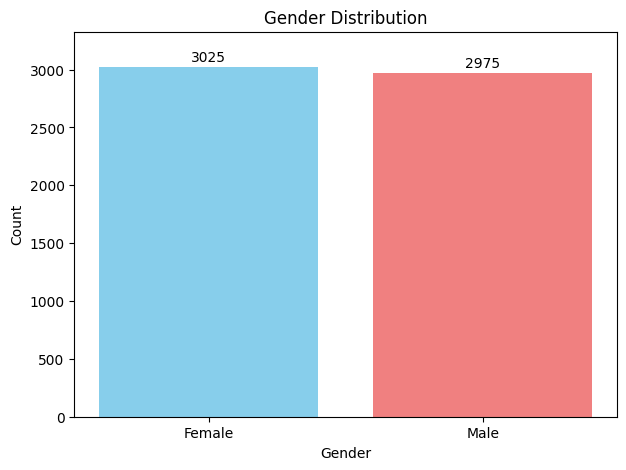

In [51]:
import matplotlib.pyplot as plt

gender_counts = dataali['Gender'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue', 'lightcoral'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')

# Add count labels on top of the bars
for index, value in enumerate(gender_counts.values):
    plt.text(index, value + 20, str(value), ha='center', va='bottom') # Adjust +20 for better positioning

plt.ylim(0, max(gender_counts.values) * 1.1) # Adjust y-axis limit to accommodate labels
plt.show()

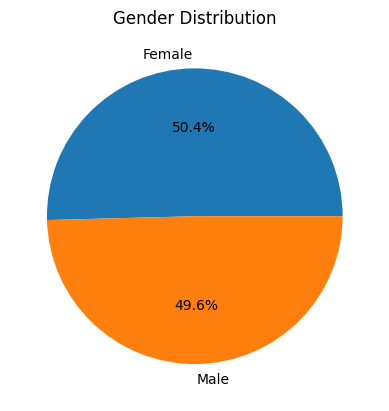

In [52]:
gender_counts = dataali['Gender'].value_counts()

plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

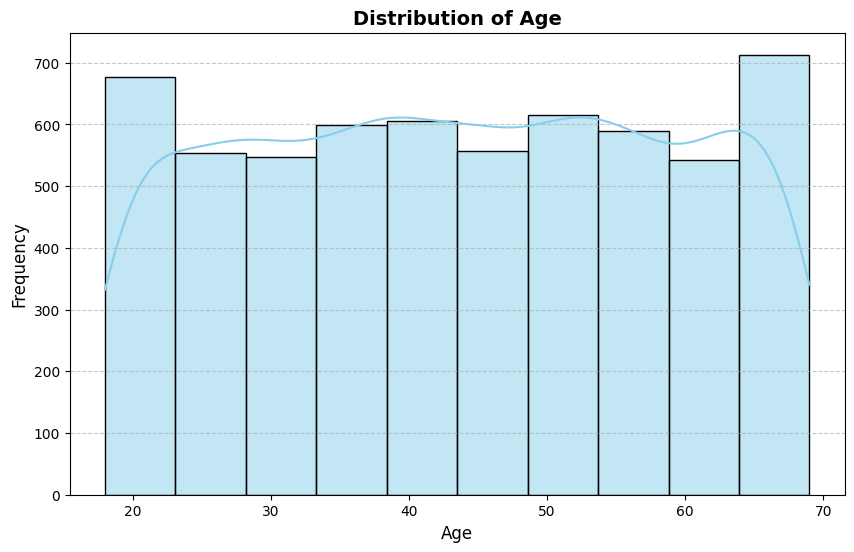

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) # Set a good figure size
sns.histplot(dataali['Age'], bins=10, kde=True, color='skyblue', edgecolor='black') # Using seaborn's histplot
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Age', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

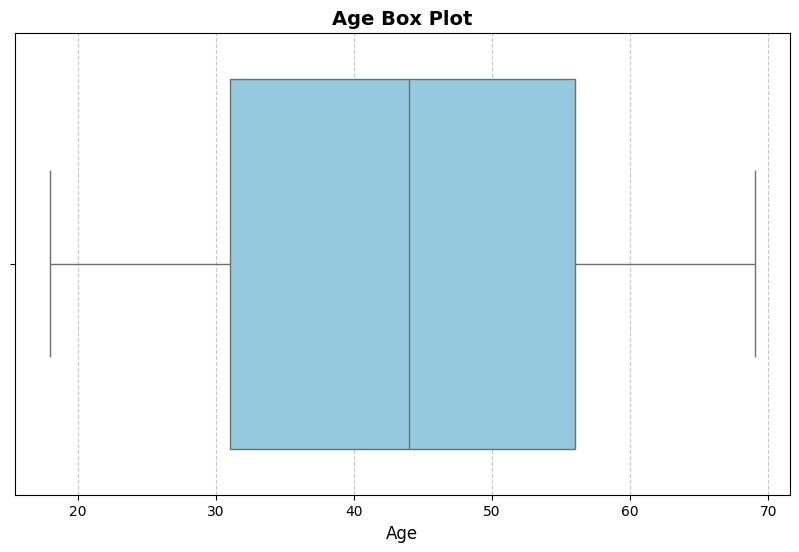

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6)) # Set a good figure size
sns.boxplot(x=dataali['Age'], color='skyblue') # Changed palette to color for a single box plot
plt.title('Age Box Plot', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.xticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show()

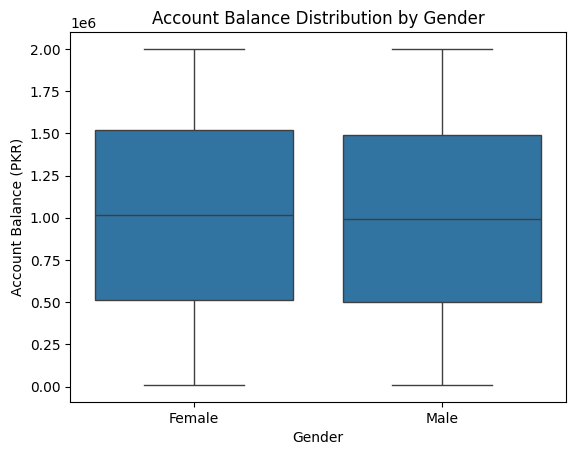

In [63]:
sns.boxplot(x='Gender', y='Account_Balance_PKR', data=dataali)
plt.title('Account Balance Distribution by Gender')
plt.ylabel('Account Balance (PKR)')
plt.show()

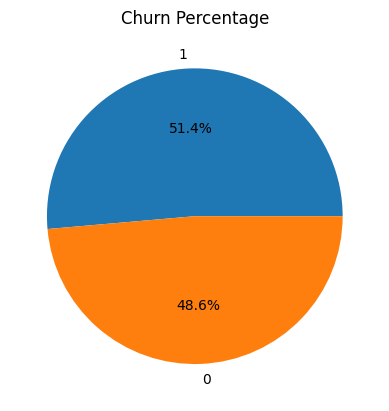

In [71]:
churn_counts = dataali['Churn'].value_counts()

plt.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%')
plt.title('Churn Percentage')
plt.show()

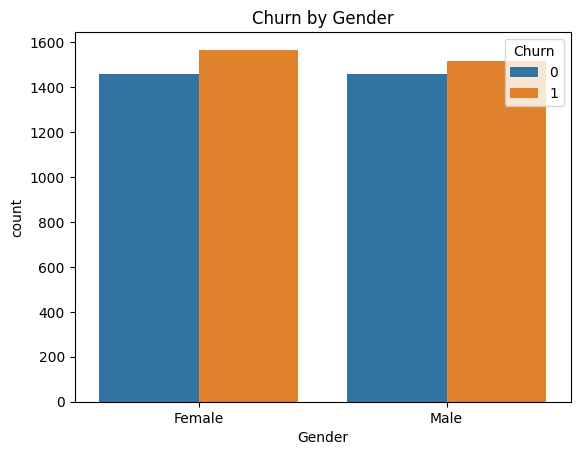

In [72]:
sns.countplot(x='Gender', hue='Churn', data=dataali)
plt.title('Churn by Gender')
plt.show()

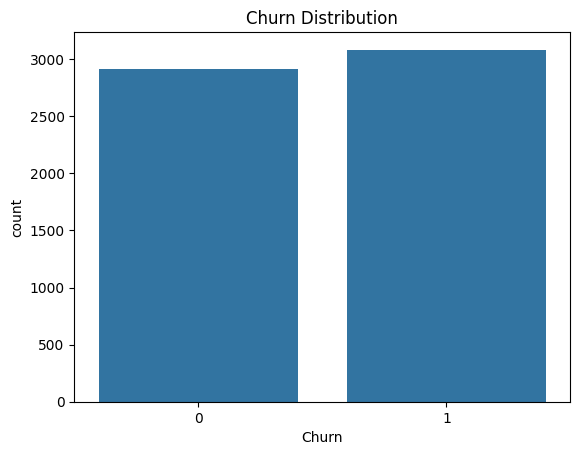

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=dataali)
plt.title('Churn Distribution')
plt.show()

#MACHINE LEARNING (TARGET CLASSIFICATION)

In [12]:
dataali.head(3)

,Customer_ID,Age,Gender,City,Bank_Name,Account_Balance_PKR,Loan_Status,Credit_Score,Account_Type,Churn
0,1,56,Female,Karachi,UBL,1214138,No,455,Current,0
1,2,69,Female,Lahore,Allied Bank,1860696,No,682,Savings,0
2,3,46,Female,Faisalabad,UBL,1681369,Yes,619,Current,1


In [13]:
#DECIDE  X, Y (X=TRAINING DATA , Y=TARGET DATA)

In [15]:
y = dataali["Churn"]

#Train Test Split

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
#library
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [18]:
x = dataali.drop("Churn", axis=1)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
x=dataali.iloc[:, :-1]

In [20]:
x.head(2)

,Customer_ID,Age,Gender,City,Bank_Name,Account_Balance_PKR,Loan_Status,Credit_Score,Account_Type
0,1,56,Female,Karachi,UBL,1214138,No,455,Current
1,2,69,Female,Lahore,Allied Bank,1860696,No,682,Savings


In [21]:
y=dataali.iloc[:,5]

In [22]:
y

,Account_Balance_PKR
0,1214138
1,1860696
2,1681369
3,60650
4,1727765
...,...
5995,1283452
5996,470153
5997,542374
5998,990086


In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [25]:
#verify
x_train.shape

(4800, 9)

In [26]:
x_test.shape

(1200, 9)

In [27]:
!pip install scikit-learn

In [28]:
!apt

apt 2.4.14 (amd64)
Usage: apt [options] command

apt is a commandline package manager and provides commands for
searching and managing as well as querying information about packages.
It provides the same functionality as the specialized APT tools,
like apt-get and apt-cache, but enables options more suitable for
interactive use by default.

Most used commands:
  list - list packages based on package names
  search - search in package descriptions
  show - show package details
  install - install packages
  reinstall - reinstall packages
  remove - remove packages
  autoremove - Remove automatically all unused packages
  update - update list of available packages
  upgrade - upgrade the system by installing/upgrading packages
  full-upgrade - upgrade the system by removing/installing/upgrading packages
  edit-sources - edit the source information file
  satisfy - satisfy dependency strings

See apt(8) for more information about the available commands.
Configuration options and syntax is

In [29]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
# Select only numerical columns for scaling.
# Note: 'Age' and 'Fare' may still be string type due to previous operations.
# You should ensure they are numerical and handle their missing values appropriately
# before scaling if you intend to include them.
numerical_cols = x_train.select_dtypes(include=np.number).columns
scaler.fit(x_train[numerical_cols])

StandardScaler()

In [30]:
Scaled_x_train=scaler.transform(x_train[numerical_cols])
Scaled_x_test=scaler.transform(x_test[numerical_cols])

In [31]:
Scaled_x_train

array([[ 0.73172419,  1.10882957,  0.89531005, -1.69427521],
       [ 1.10635374, -0.17271318, -1.48579619,  0.18232268],
       [ 0.49678702, -1.58915516, -0.59747639, -0.82771166],
       ...,
       [-1.00230842,  0.77158148,  0.22724486, -0.27104501],
       [ 0.57471458,  0.70413186, -0.38672729,  0.41761477],
       [-1.70538821,  0.09708529,  1.40799483, -1.55080443]])

In [32]:
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#fit predict score

#1-KNN

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

# Correctly defining x and y for a classification task based on the current dataset.

# 1. Define y as the target 'Churn'
y = dataali["Churn"]

# 2. Define x as features, dropping 'Customer_ID' and the target 'Churn'
x = dataali.drop(columns=["Customer_ID", "Churn"])

# 3. Numerical columns ('Age', 'Account_Balance_PKR', 'Credit_Score') are already in correct format (int64) and have no missing values.
#    No need for `pd.to_numeric` or `fillna` for these, unlike the original comments that were for a different dataset.

# 4. Handle categorical columns in x: 'Gender', 'City', 'Bank_Name', 'Loan_Status', 'Account_Type'
#    These were correctly identified as 'object' Dtype in dataali.info()
le = LabelEncoder()
x['Gender'] = le.fit_transform(x['Gender'])
x['City'] = le.fit_transform(x['City'])
x['Bank_Name'] = le.fit_transform(x['Bank_Name'])
x['Loan_Status'] = le.fit_transform(x['Loan_Status'])
x['Account_Type'] = le.fit_transform(x['Account_Type'])

# 5. Re-split data into training and testing sets with the corrected x and y
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 6. Scale numerical features (all features in x are now numerical after LabelEncoding)
scaler = StandardScaler()
Scaled_x_train = scaler.fit_transform(x_train) # Fit and transform on the new x_train
Scaled_x_test = scaler.transform(x_test) # Transform x_test using the scaler fitted on x_train

# Now, fit the KNN model using the scaled features and the correct target labels
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(Scaled_x_train, y_train)


KNeighborsClassifier(n_neighbors=3)

In [36]:
y_pred = knn.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [37]:
accuracy = knn.score(x_test, y_test)
print("Accuracy:", accuracy, "%")

Accuracy: 0.4716666666666667 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


#2-RANDOM FOREST

In [38]:
#library
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [39]:
RF = RandomForestClassifier()

RF.fit(x_train, y_train)

RandomForestClassifier()

In [40]:
y_pred = RF.predict(x_test)

In [41]:
accuracy = RF.score(x_test, y_test)
print("Accuracy:", accuracy, "%")

Accuracy: 0.5041666666666667 %


#3-loGISTIC REGRESSION

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
LF = LogisticRegression()

LF.fit(x_train, y_train)

LogisticRegression()

In [44]:
y_pred = LF.predict(x_test)

In [45]:
accuracy = LF.score(x_test, y_test)
print("Accuracy:", accuracy, "%")

Accuracy: 0.47833333333333333 %
